Translated code from Matlab to Python is folded. Note that the learning rate was changed from the default 0.001 to 0.01.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================

def get_skeletons():
    # Digit 0
    digit0 = np.zeros((25, 25))
    for ii in range(25):
        for jj in range(25):
            if abs(np.sqrt((ii-12)**2 + (jj-12)**2) - 8) < 1:
                digit0[ii, jj] = 1
    
    # Digit 1
    digit1 = np.zeros((25, 25))
    for ii in range(4, 21):
        digit1[ii, 12] = 1
    digit1[20, 11] = 1
    digit1[20, 10] = 1
    digit1[20, 13] = 1
    digit1[20, 14] = 1
    digit1[4, 11] = 1

    # Digit X
    digitX = np.zeros((25, 25))
    for ii in range(4, 21):
        digitX[ii, ii] = 1
        digitX[ii, 24 - ii] = 1

    return digit0, digit1, digitX

# =======================================

def batch_of_30(digit0, digit1, digitX):
    X = np.zeros((625, 30))
    MM, NN = np.meshgrid(np.arange(25), np.arange(25), indexing='ij')
    for nX in range(30):
        rr = np.random.rand()
        if rr < 1 / 3:
            dg = digit0
        elif rr < 2 / 3:
            dg = digit1
        else:
            dg = digitX
        dgn = 1 / np.sum(dg)
        dd = np.zeros((25, 25))

        non_zero_indicies = np.argwhere(dg != 0)

        for ii, jj in non_zero_indicies:
            id_val = np.random.randn()
            jd_val = np.random.randn()
            dist_sq = (MM - ii - id_val) ** 2 + (NN - jj - jd_val) ** 2
            dd += np.exp(-dist_sq)
        dd = dgn * dd
        X[:, nX] = dd.flatten(order='F')
    return X

# ===================================

def train_linear_autoencoder(M = 3):
    digit0, digit1, digitX = get_skeletons()
    TraingCycle = 5000
    lam = 0.01

    x = np.ones((626, 30))
    u = np.zeros((M, 30))
    sigprime = np.ones((M, 30))
    y = np.ones((M + 1, 30))
    z = np.zeros((625, 30))

    V = 0.01 * np.random.randn(M, 626)
    W = 0.01 * np.random.randn(625, M + 1)

    Err = np.zeros(TraingCycle)

    print("[ + ] Training Start...")
    for ii in range(TraingCycle):
        X_batch = batch_of_30(digit0, digit1, digitX)
        x[:625, :] = X_batch

        # Forward Propagation
        u = V @ x
        y[:M, :] = u
        z = W @ y

        epsilon = z - x[:625, :]
        Err[ii] = np.sum(epsilon * epsilon) / (2 * 30)

        # Backward Propagation
        w = W[:, :M]
        delta = sigprime * (w.T @ epsilon)
        W = W - lam * (epsilon @ y.T)
        V = V - lam * (delta @ x.T)

        if (ii + 1) % 500 == 0:
            print(f"[ + ] Epoch {ii + 1} / {TraingCycle}, Loss: {Err[ii]:.4f}")

    plt.figure(figsize=(6, 4))
    plt.plot(Err)
    plt.title('Error')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss E')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, M, figsize=(4 * M, 4))
    
    if M == 1:
        axes = [axes]
        
    for i in range(M):
        pattern = V[i, :625].reshape(25, 25, order='F')
        im = axes[i].imshow(pattern, cmap='viridis')
        axes[i].set_title(f'Pattern of V{i+1}')
        
    plt.tight_layout()
    plt.show()

    return V, W, x

# ==========================================

def check_io_patterns(V, W, x_batch, M = 3):
    m = np.random.randint(0, 30)
    x1 = x_batch[:, m].reshape(-1, 1)
    u1 = V @ x1
    y1 = np.ones((M + 1, 1))
    y1[:M, 0] = u1[:, 0]
    z1 = W @ y1

    A1 = x1[:625, 0].reshape(25, 25, order='F')
    B1 = z1[:, 0].reshape(25, 25, order='F')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(A1, cmap='viridis')
    axes[0].set_title(f"Input Pattern (Sample {m})")
    im1 = axes[1].imshow(B1, cmap='viridis')
    axes[1].set_title(f'Reconstructed Output')
    plt.show()

### Part a

Run the code TrainLinearAutoencoder to see how it works.

[ + ] Training Start...
[ + ] Epoch 500 / 5000, Loss: 0.0296
[ + ] Epoch 1000 / 5000, Loss: 0.0203
[ + ] Epoch 1500 / 5000, Loss: 0.0176
[ + ] Epoch 2000 / 5000, Loss: 0.0136
[ + ] Epoch 2500 / 5000, Loss: 0.0170
[ + ] Epoch 3000 / 5000, Loss: 0.0130
[ + ] Epoch 3500 / 5000, Loss: 0.0132
[ + ] Epoch 4000 / 5000, Loss: 0.0148
[ + ] Epoch 4500 / 5000, Loss: 0.0152
[ + ] Epoch 5000 / 5000, Loss: 0.0143


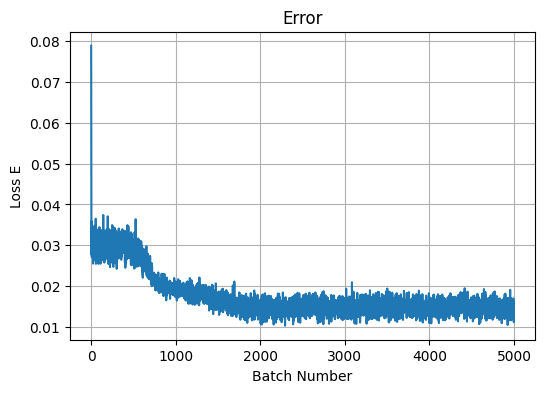

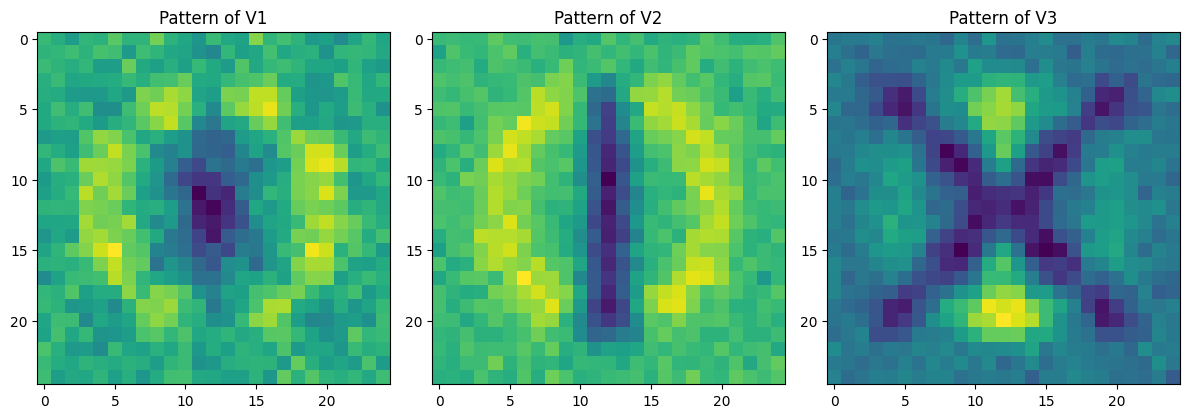

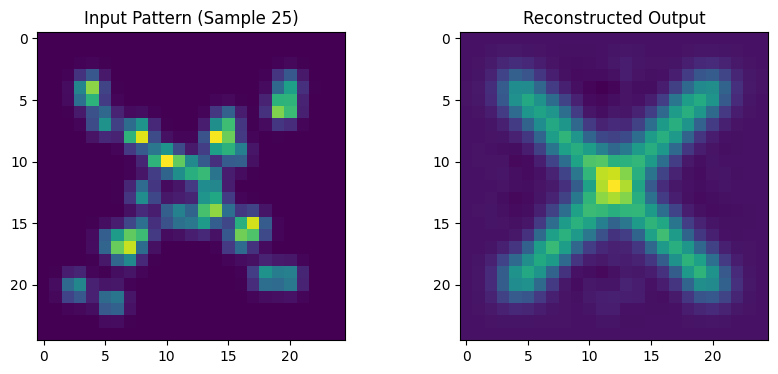

In [3]:
trained_V, trained_W, last_x_batch = train_linear_autoencoder(M = 3)
check_io_patterns(trained_V, trained_W, last_x_batch, M = 3)

1. **Convergence Process**: The loss droped to around 0.03 very rapidly at the beginning of the training process. After oscillating around 0.03 for about 750 batches, the loss further droped to around 0.015 and remained at the level. The drop from 0.03 to 0.015 could be that the model escaped a local minimum and evolved to the global minimum. The remaining 0.015 is caused by the randomness of the data that the model won't be able to predict.
2. **Patterns**: We can clearly see from the patterns that, instead of being independent "0", "1" and "X" digits, the patterns showed the linear combination of these digits with clear positive and negative weights. With the linear combination of the three patterns, the single digits can be reconstructed.
3. **Reconstruction**: Comparing to the noisy random input image, the reconstructed image is smooth and clear. When training the model, it ignored the unpredictable noise and kept the iconic structure information. Therefore, when reconstructing from the three hidden nodes, the results is smooth and clear.

### Part b
Increase the number of elements in the hidden layer to 5 and repeat the experiment.

[ + ] Training Start...
[ + ] Epoch 500 / 5000, Loss: 0.0253
[ + ] Epoch 1000 / 5000, Loss: 0.0172
[ + ] Epoch 1500 / 5000, Loss: 0.0131
[ + ] Epoch 2000 / 5000, Loss: 0.0146
[ + ] Epoch 2500 / 5000, Loss: 0.0140
[ + ] Epoch 3000 / 5000, Loss: 0.0181
[ + ] Epoch 3500 / 5000, Loss: 0.0134
[ + ] Epoch 4000 / 5000, Loss: 0.0187
[ + ] Epoch 4500 / 5000, Loss: 0.0136
[ + ] Epoch 5000 / 5000, Loss: 0.0151


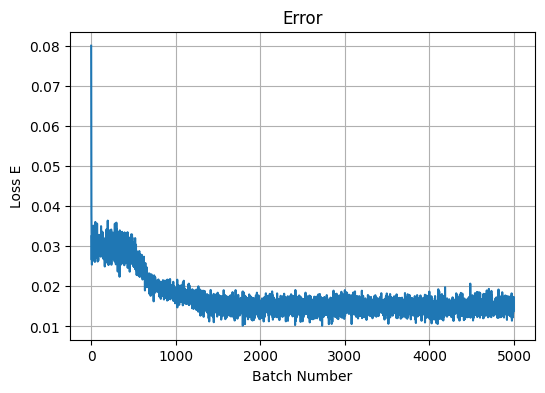

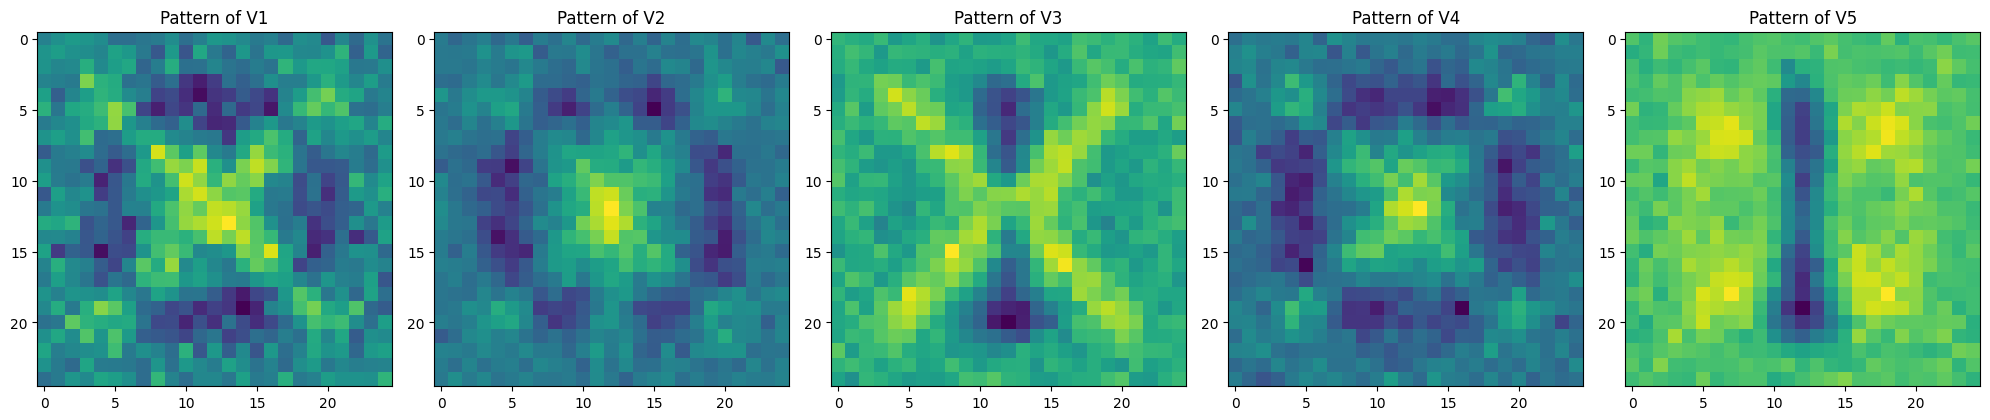

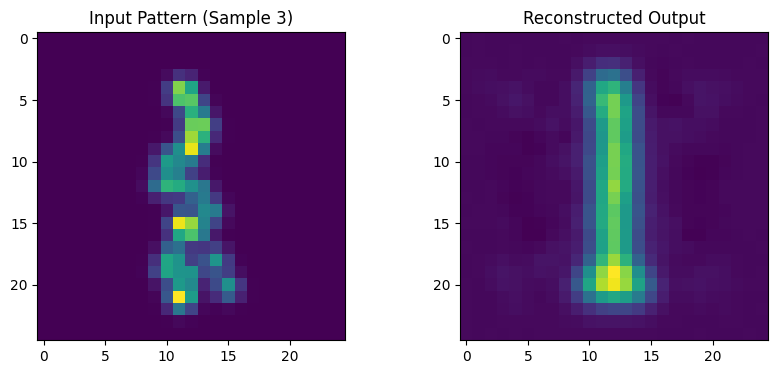

In [4]:
trained_V, trained_W, last_x_batch = train_linear_autoencoder(M = 5)
check_io_patterns(trained_V, trained_W, last_x_batch, M = 5)

The model with 5 elements in the hidden layer showed similar results, with 4 different linear combinations of the digits, as the second the the fourth appear to be the same. The loss is similar, because we need no more than 3 nodes to fully represent the three digits.

### Part c
Decrease the number of elements in the hidden layer to 2 and repeat the experiment.

[ + ] Training Start...
[ + ] Epoch 500 / 5000, Loss: 0.0284
[ + ] Epoch 1000 / 5000, Loss: 0.0204
[ + ] Epoch 1500 / 5000, Loss: 0.0192
[ + ] Epoch 2000 / 5000, Loss: 0.0165
[ + ] Epoch 2500 / 5000, Loss: 0.0132
[ + ] Epoch 3000 / 5000, Loss: 0.0153
[ + ] Epoch 3500 / 5000, Loss: 0.0147
[ + ] Epoch 4000 / 5000, Loss: 0.0155
[ + ] Epoch 4500 / 5000, Loss: 0.0174
[ + ] Epoch 5000 / 5000, Loss: 0.0134


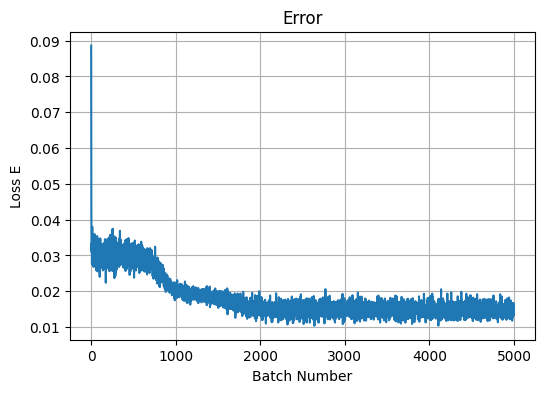

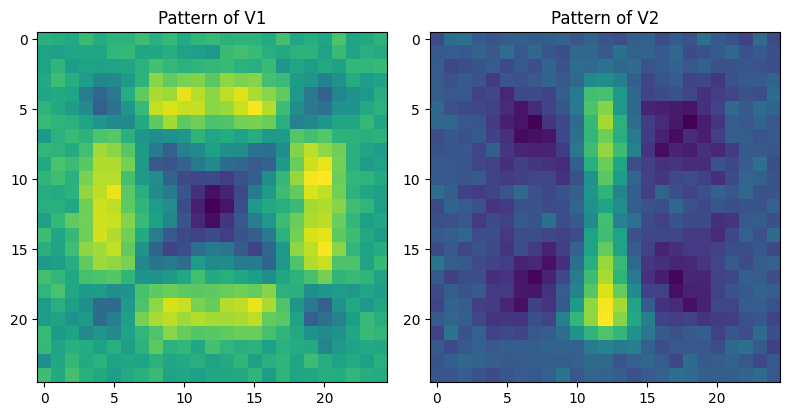

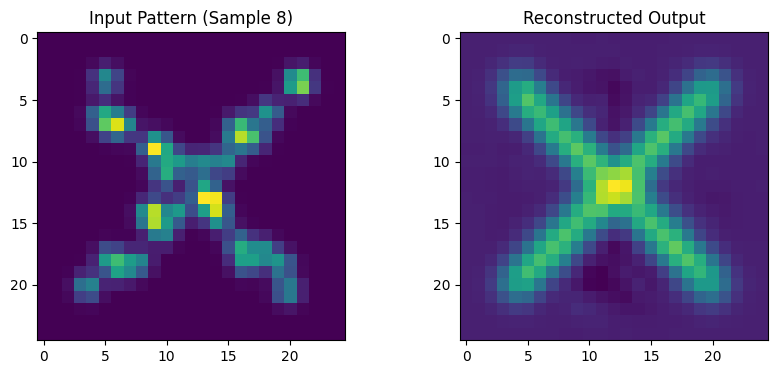

In [5]:
trained_V, trained_W, last_x_batch = train_linear_autoencoder(M = 2)
check_io_patterns(trained_V, trained_W, last_x_batch, M = 2)

Now with only 2 elements in the hidden layer, the three digits cannot be all independently extracted. In this example, the "X" digit is always combined with either the "0" or "1" digit. The reconstructed graph also demonstrates the phenomenon, in which there is a negative "1" digit with the "X" digit. Surprisingly, the loss still remained at about 0.015.

### Part d
Implement a nonlinear autoencoder, with the ReLU activation function applied at the hidden layer.

In [7]:
# ===================================

def train_linear_autoencoder_relu(M = 3):
    digit0, digit1, digitX = get_skeletons()
    TraingCycle = 5000
    lam = 0.01

    x = np.ones((626, 30))
    u = np.zeros((M, 30))
    y = np.ones((M + 1, 30))
    z = np.zeros((625, 30))

    V = 0.01 * np.random.randn(M, 626)
    W = 0.01 * np.random.randn(625, M + 1)

    Err = np.zeros(TraingCycle)

    print("[ + ] Training Start...")
    for ii in range(TraingCycle):
        X_batch = batch_of_30(digit0, digit1, digitX)
        x[:625, :] = X_batch

        # Forward Propagation
        u = V @ x
        y[:M, :] = np.maximum(0, u)
        z = W @ y

        epsilon = z - x[:625, :]
        Err[ii] = np.sum(epsilon * epsilon) / (2 * 30)

        # Backward Propagation
        sigprime = (u > 0).astype(float)
        w = W[:, :M]
        delta = sigprime * (w.T @ epsilon)
        W = W - lam * (epsilon @ y.T)
        V = V - lam * (delta @ x.T)

        if (ii + 1) % 500 == 0:
            print(f"[ + ] Epoch {ii + 1} / {TraingCycle}, Loss: {Err[ii]:.4f}")

    plt.figure(figsize=(6, 4))
    plt.plot(Err)
    plt.title('Error')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss E')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, M, figsize=(4 * M, 4))
    
    if M == 1:
        axes = [axes]
        
    for i in range(M):
        pattern = V[i, :625].reshape(25, 25, order='F')
        im = axes[i].imshow(pattern, cmap='viridis')
        axes[i].set_title(f'Pattern of V{i+1}')
        
    plt.tight_layout()
    plt.show()

    return V, W, x

# ==========================================

def check_io_patterns_relu(V, W, x_batch, M = 3):
    m = np.random.randint(0, 30)
    x1 = x_batch[:, m].reshape(-1, 1)
    u1 = V @ x1
    y1 = np.ones((M + 1, 1))
    y1[:M, 0] = np.maximum(0, u1[:, 0])
    z1 = W @ y1

    A1 = x1[:625, 0].reshape(25, 25, order='F')
    B1 = z1[:, 0].reshape(25, 25, order='F')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(A1, cmap='viridis')
    axes[0].set_title(f"Input Pattern (Sample {m})")
    im1 = axes[1].imshow(B1, cmap='viridis')
    axes[1].set_title(f'Reconstructed Output')
    plt.show()

[ + ] Training Start...
[ + ] Epoch 500 / 5000, Loss: 0.0263
[ + ] Epoch 1000 / 5000, Loss: 0.0208
[ + ] Epoch 1500 / 5000, Loss: 0.0160
[ + ] Epoch 2000 / 5000, Loss: 0.0159
[ + ] Epoch 2500 / 5000, Loss: 0.0141
[ + ] Epoch 3000 / 5000, Loss: 0.0128
[ + ] Epoch 3500 / 5000, Loss: 0.0156
[ + ] Epoch 4000 / 5000, Loss: 0.0153
[ + ] Epoch 4500 / 5000, Loss: 0.0165
[ + ] Epoch 5000 / 5000, Loss: 0.0154


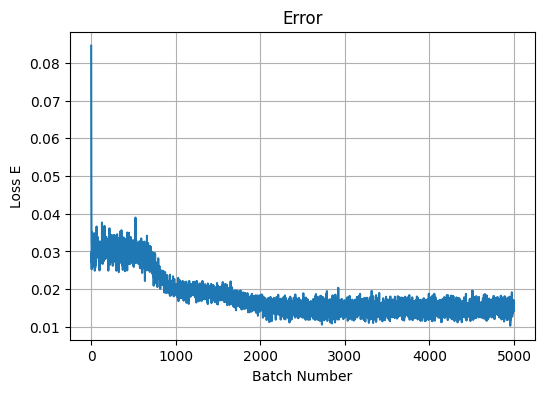

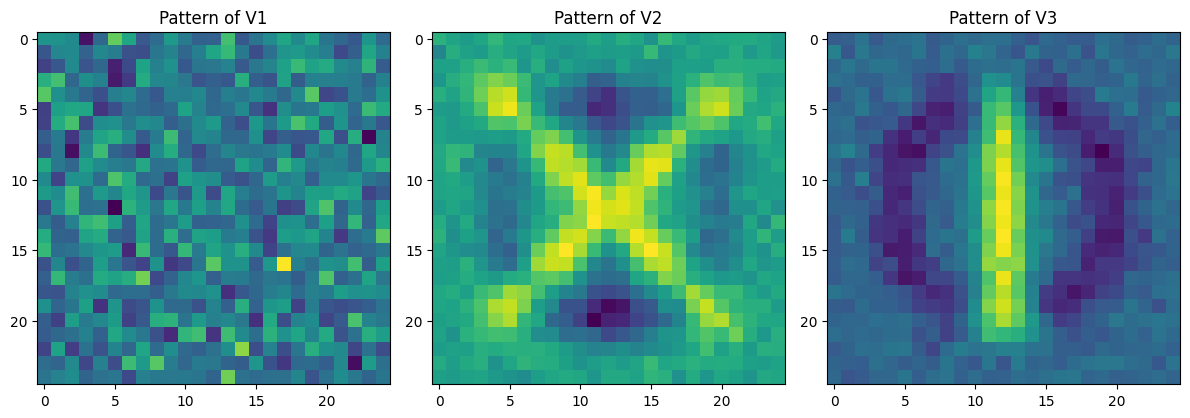

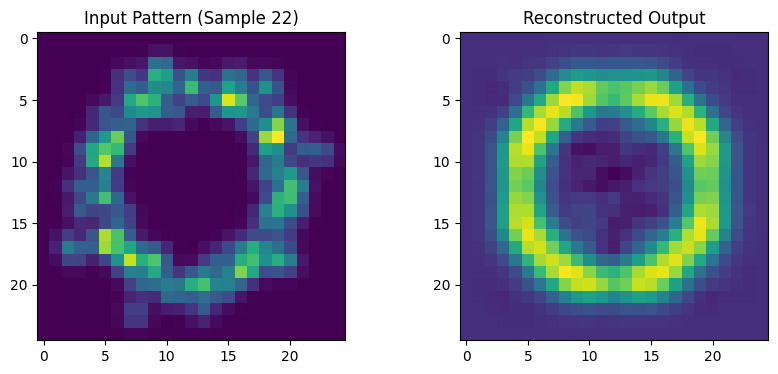

In [9]:
trained_V, trained_W, last_x_batch = train_linear_autoencoder_relu(M = 3)
check_io_patterns_relu(trained_V, trained_W, last_x_batch, M = 3)

Now with ReLU activation function, several interesting phenomenon were noticed.

1. **Convergence Process**: The convergence process is basically the same with the previous models, dropping to 0.03 rapidly and slowly drop to 0.015 later on.
2. **Patterns**: We notice the first pattern is just random noise without any visuable patterns. In early learning stage or the random initial values, the output of V1 is always negative, and with the ReLU activation function, the backward propagation completely ignored the V1 node. Therefore, the model works similar with the model of 2 hidden nodes. With special initial values, the problem may be able to be solved.
3. **Reconstruction**: Similar to Part c, the "0" digit pattern is combined with a negative combination of "1" and "X" digit.